In [ ]:
# ! pip install pandas
# !pip install pyarrow python-dotenv
# !pip install sentence-transformers scikit-learn seaborn


In [11]:
import os
from dotenv import load_dotenv
import numpy as np

load_dotenv()

PPATH = os.getenv("PPATH")


print(PPATH)

/Users/daragama/Documents/ProyectosVarios/Datathon2026/


In [12]:
import pandas as pd

df = pd.read_parquet(PPATH + "data/dataset_conversaciones/dataset_50k_anonymized.parquet")
print(df.shape)
df.head()

(49999, 6)


,input,output,date,conv_id,user_id,channel_source
0,"Me enteré de una promo ""Supercashback Pagos Gu...",Claro que puedo ayudarte! Para participar en l...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
1,La tarjeta de crédito Hey Negocios es diferent...,Claro! La Tarjeta de Crédito Hey Negocios es d...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
2,"Entiendo, gracias",¡De nada! Me alegra haber podido ayudarte. Si ...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
3,Hola,¡Hola! ¿Cómo estás? Estoy aquí para ayudarte c...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1
4,Verificación de cuenta,Claro que puedo ayudarte con eso. Para validar...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1


In [13]:

df_in_conversations = (
    df.groupby("conv_id", as_index=False)
    .agg(
        user_id=("user_id", "first"),
        conv_text=("input", lambda x: " ".join(x.dropna().astype(str))),
    )
)
df_out_conversations = (
    df.groupby("conv_id", as_index=False)
    .agg(
        user_id=("user_id", "first"),
        conv_text=("output", lambda x: " ".join(x.dropna().astype(str))),
    )
)

df_in_conversations.head()
df_out_conversations.head()

,conv_id,user_id,conv_text
0,0000ACA6-AA00-4227-BCE7-5E78C2742D88,USR-12729,Claro! La tasa anual fija para el Crédito de A...
1,00043647-377f-4528-b2b3-425afd81f6bd,USR-11649,Lamento escuchar eso. Si no puedes seleccionar...
2,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,Claro que puedo ayudarte! Para participar en l...
3,000DD932-B649-41FF-9B2A-EB08B33F5072,USR-10602,"Si necesitas hablar con un asesor, solo tienes..."
4,00149741-F4D6-4BC9-B8FB-6FFD398FD73F,USR-01560,"Claro que sí, te comento que el Centro de Aten..."


# WORDCLOUD

In [14]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("spanish"))

from manual_stopwords import manual_stop_words

stop_words = stop_words.union(manual_stop_words)

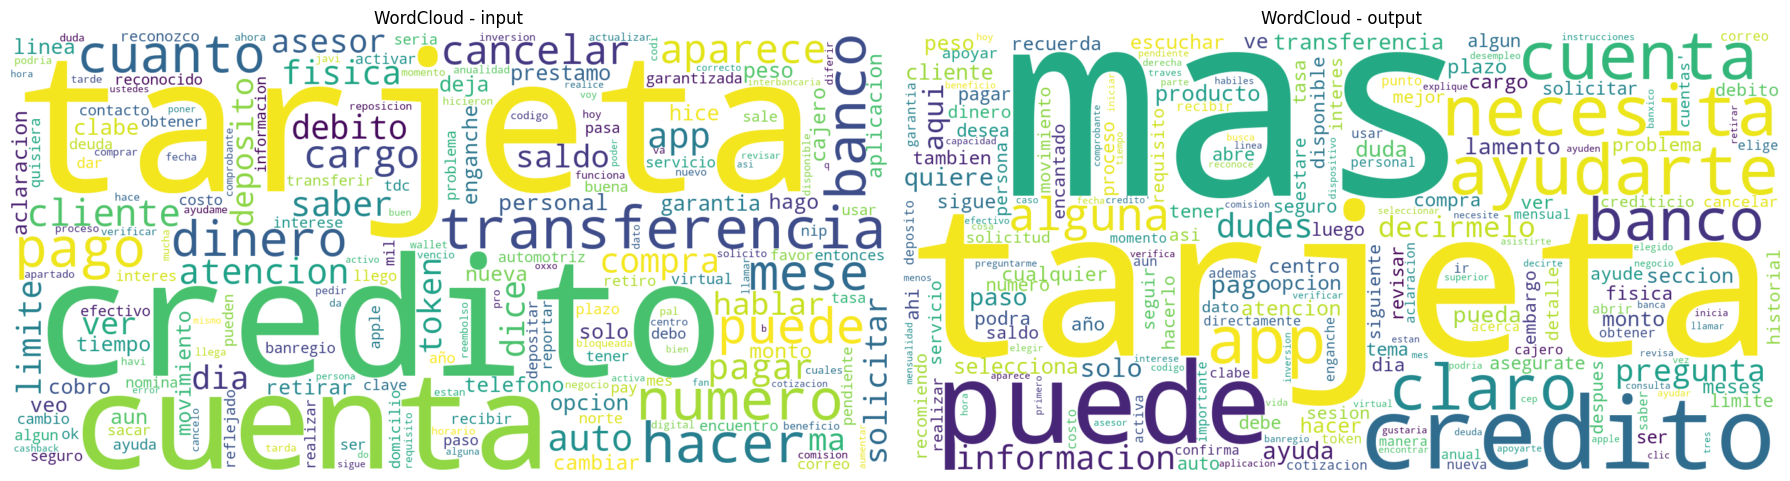

In [15]:
def normalizar_texto(texto: str) -> str:
    texto = texto.lower()
    texto = texto.replace("á", "a")
    texto = texto.replace("é", "e")
    texto = texto.replace("í", "i")
    texto = texto.replace("ó", "o")
    texto = texto.replace("ú", "u")
    texto = texto.replace("ü", "u")
    return texto


# Combine text, removing null values and forcing string conversion
text_input = " ".join(df_in_conversations["conv_text"].dropna().astype(str))
text_output = " ".join(df_out_conversations["conv_text"].dropna().astype(str))

text_input = normalizar_texto(text_input)
text_output = normalizar_texto(text_output)

wc_input = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    collocations=False,
    stopwords=stop_words,
).generate(text_input)

wc_output = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    collocations=False,
    stopwords=stop_words,
).generate(text_output)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(wc_input, interpolation="bilinear")
axes[0].set_title("WordCloud - input")
axes[0].axis("off")

axes[1].imshow(wc_output, interpolation="bilinear")
axes[1].set_title("WordCloud - output")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# CLUSTERING - USUARIO

In [16]:
# Preprocesamiento INPUT para clustering: normalizar + quitar stopwords
def limpiar_para_clustering(texto: str) -> str:
    texto = normalizar_texto(str(texto))
    tokens = [t for t in texto.split() if t not in stop_words]
    return " ".join(tokens)

df_in_pre = df_in_conversations.copy()
df_in_pre["conv_text_clean"] = df_in_pre["conv_text"].fillna("").astype(str).apply(limpiar_para_clustering)

df_in_pre.head()

,conv_id,user_id,conv_text,conv_text_clean
0,0000ACA6-AA00-4227-BCE7-5E78C2742D88,USR-12729,Cuál es su tasa de interés para el crédito de ...,tasa interes credito automovil?
1,00043647-377f-4528-b2b3-425afd81f6bd,USR-11649,No le deja seleccionar el cobro para hacer la ...,deja seleccionar cobro hacer aclaracion
2,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,"Me enteré de una promo ""Supercashback Pagos Gu...","entere promo ""supercashback pagos gubernamenta..."
3,000DD932-B649-41FF-9B2A-EB08B33F5072,USR-10602,Ocupo asistencia humana,ocupo asistencia humana
4,00149741-F4D6-4BC9-B8FB-6FFD398FD73F,USR-01560,Atención a clientes,atencion clientes


In [17]:
# Clustering INPUT con embeddings semanticos (solo KMeans)
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

texts_in = df_in_pre["conv_text_clean"].tolist()

model_st = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embeddings_in = model_st.encode(
    texts_in,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)

labels_in_kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto").fit_predict(embeddings_in)

df_clusters_in = df_in_pre.copy()
df_clusters_in["cluster_kmeans"] = labels_in_kmeans

sil_in = silhouette_score(embeddings_in, labels_in_kmeans, metric="euclidean")
print("INPUT - KMeans:")
print(pd.Series(labels_in_kmeans).value_counts().sort_index())
print(f"Silhouette INPUT: {sil_in:.3f}")

df_clusters_in.head()

/Users/daragama/Documents/ProyectosVarios/Datathon2026/datathon26/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 754/754 [00:23<00:00, 32.56it/s]


INPUT - KMeans:
0    6605
1    7887
2    9627
Name: count, dtype: int64
Silhouette INPUT: 0.070


,conv_id,user_id,conv_text,conv_text_clean,cluster_kmeans
0,0000ACA6-AA00-4227-BCE7-5E78C2742D88,USR-12729,Cuál es su tasa de interés para el crédito de ...,tasa interes credito automovil?,1
1,00043647-377f-4528-b2b3-425afd81f6bd,USR-11649,No le deja seleccionar el cobro para hacer la ...,deja seleccionar cobro hacer aclaracion,2
2,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,"Me enteré de una promo ""Supercashback Pagos Gu...","entere promo ""supercashback pagos gubernamenta...",1
3,000DD932-B649-41FF-9B2A-EB08B33F5072,USR-10602,Ocupo asistencia humana,ocupo asistencia humana,2
4,00149741-F4D6-4BC9-B8FB-6FFD398FD73F,USR-01560,Atención a clientes,atencion clientes,2


## Visualizacion INPUT - KMeans

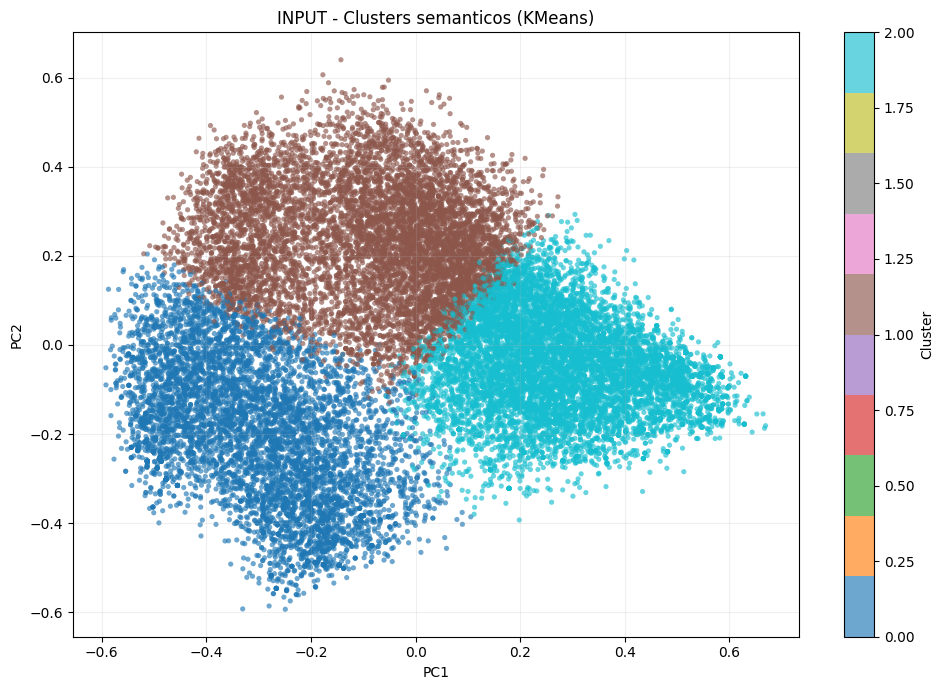

In [18]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X_in_2d = PCA(n_components=2, random_state=42).fit_transform(embeddings_in)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_in_2d[:, 0],
    X_in_2d[:, 1],
    c=labels_in_kmeans,
    cmap="tab10",
    s=14,
    alpha=0.65,
    edgecolors="none",
)
plt.title("INPUT - Clusters semanticos (KMeans)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## WordCloud por categoria (cluster) - INPUT / USUARIO

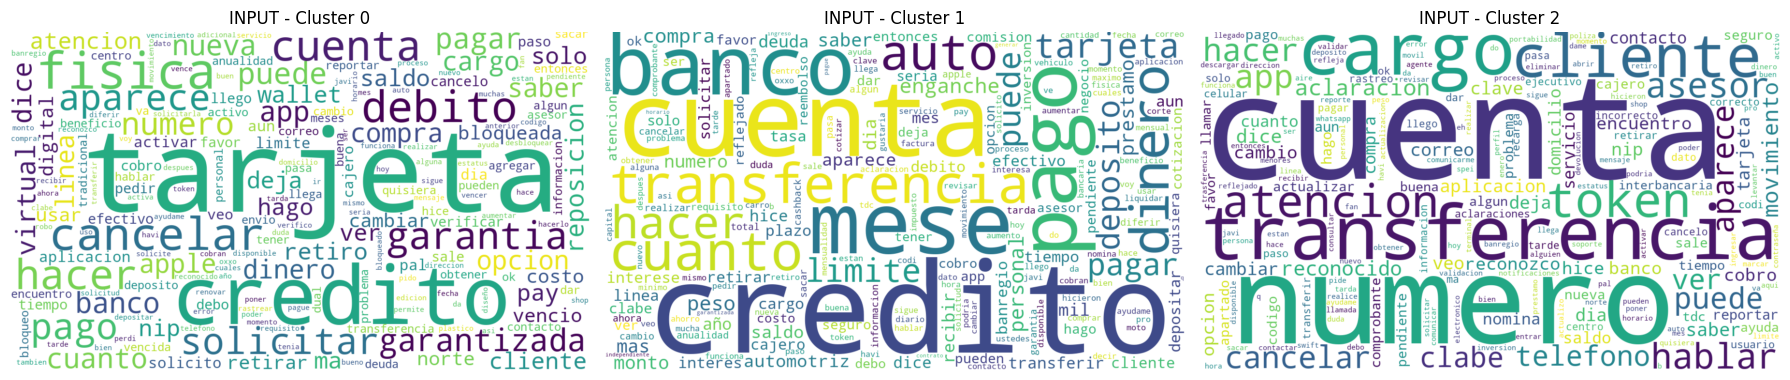

In [19]:

import math
from wordcloud import WordCloud

cluster_col = "cluster_kmeans"
clusters_in = sorted(df_clusters_in[cluster_col].dropna().unique())
n_clusters_in = len(clusters_in)

if n_clusters_in == 0:
    print("No hay clusters para graficar en INPUT.")
else:
    cols = min(3, n_clusters_in)
    rows = math.ceil(n_clusters_in / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, cl in enumerate(clusters_in):
        ax = axes[i]
        text_cluster = " ".join(
            df_clusters_in.loc[df_clusters_in[cluster_col] == cl, "conv_text_clean"]
            .dropna()
            .astype(str)
            .tolist()
        )
        if text_cluster.strip():
            wc = WordCloud(
                width=1200,
                height=700,
                background_color="white",
                collocations=False,
                stopwords=stop_words,
            ).generate(text_cluster)
            ax.imshow(wc, interpolation="bilinear")
            ax.set_title(f"INPUT - Cluster {cl}")
        else:
            ax.text(0.5, 0.5, "Sin texto", ha="center", va="center")
            ax.set_title(f"INPUT - Cluster {cl}")
        ax.axis("off")

    for j in range(n_clusters_in, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# CLUSTERING OUTPUT - HAVI

In [20]:
# Preprocesamiento + clustering OUTPUT con embeddings semanticos (solo KMeans)
from sklearn.metrics import silhouette_score

df_out_pre = df_out_conversations.copy()
df_out_pre["conv_text_clean"] = df_out_pre["conv_text"].fillna("").astype(str).apply(limpiar_para_clustering)

texts_out = df_out_pre["conv_text_clean"].tolist()
embeddings_out = model_st.encode(
    texts_out,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)

labels_out_kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto").fit_predict(embeddings_out)

df_clusters_out = df_out_pre.copy()
df_clusters_out["cluster_kmeans"] = labels_out_kmeans

sil_out = silhouette_score(embeddings_out, labels_out_kmeans, metric="euclidean")
print("OUTPUT - KMeans:")
print(pd.Series(labels_out_kmeans).value_counts().sort_index())
print(f"Silhouette OUTPUT: {sil_out:.3f}")

Batches: 100%|██████████| 754/754 [01:04<00:00, 11.61it/s]


OUTPUT - KMeans:
0    10682
1     6786
2     6651
Name: count, dtype: int64
Silhouette OUTPUT: 0.069


## Visualizacion OUTPUT - KMeans

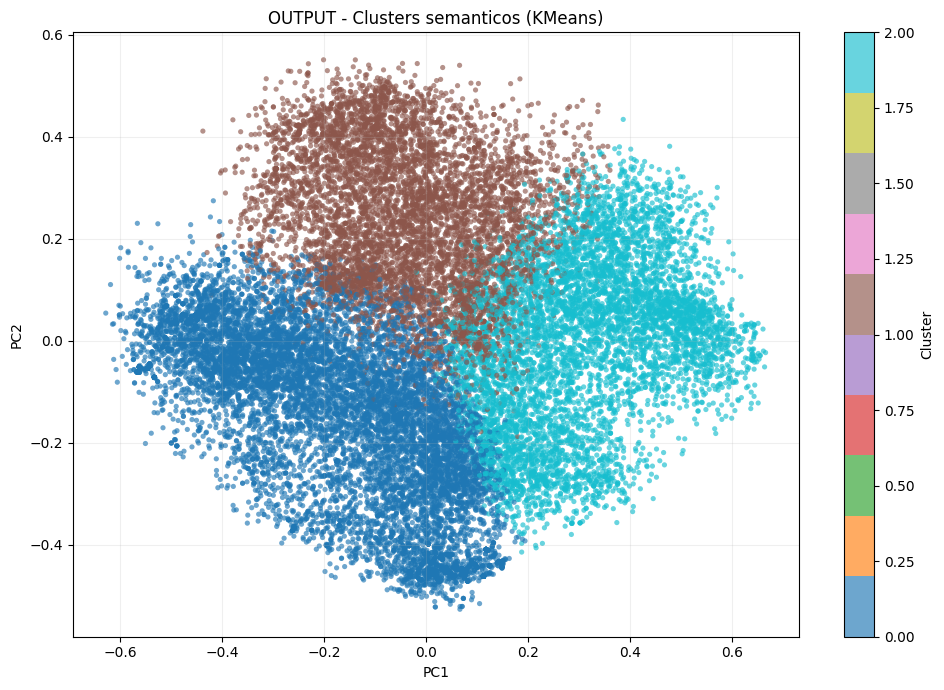

In [21]:
X_out_2d = PCA(n_components=2, random_state=42).fit_transform(embeddings_out)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_out_2d[:, 0],
    X_out_2d[:, 1],
    c=labels_out_kmeans,
    cmap="tab10",
    s=14,
    alpha=0.65,
    edgecolors="none",
)
plt.title("OUTPUT - Clusters semanticos (KMeans)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## WordCloud por categoria (cluster) - OUTPUT / HAVI

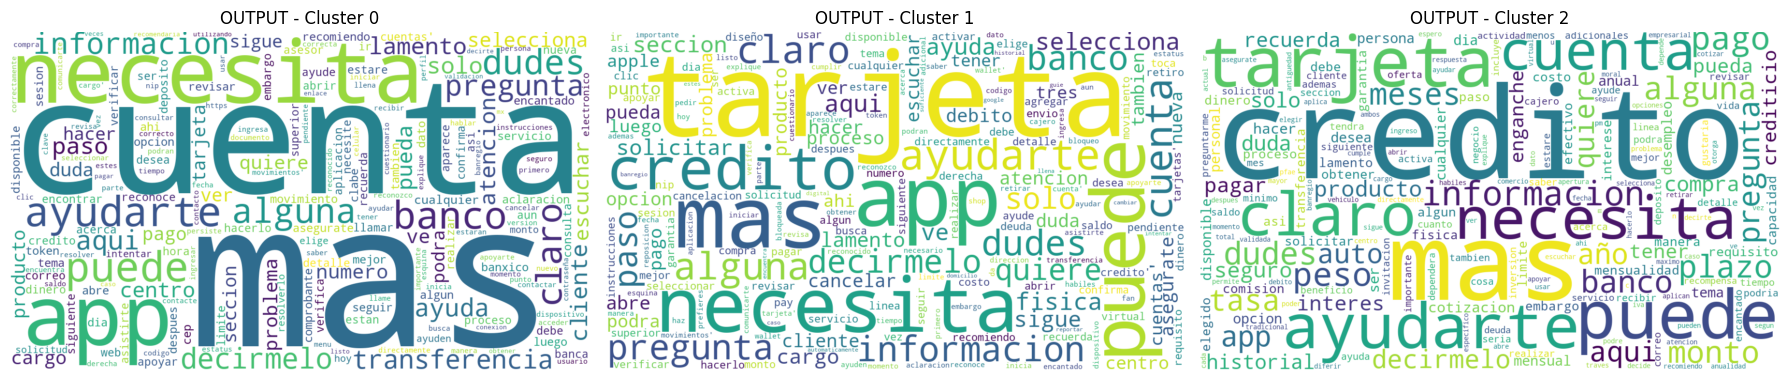

In [22]:
cluster_col = "cluster_kmeans"
clusters_out = sorted(df_clusters_out[cluster_col].dropna().unique())
n_clusters_out = len(clusters_out)

if n_clusters_out == 0:
    print("No hay clusters para graficar en OUTPUT.")
else:
    cols = min(3, n_clusters_out)
    rows = math.ceil(n_clusters_out / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, cl in enumerate(clusters_out):
        ax = axes[i]
        text_cluster = " ".join(
            df_clusters_out.loc[df_clusters_out[cluster_col] == cl, "conv_text_clean"]
            .dropna()
            .astype(str)
            .tolist()
        )
        if text_cluster.strip():
            wc = WordCloud(
                width=1200,
                height=700,
                background_color="white",
                collocations=False,
                stopwords=stop_words,
            ).generate(text_cluster)
            ax.imshow(wc, interpolation="bilinear")
            ax.set_title(f"OUTPUT - Cluster {cl}")
        else:
            ax.text(0.5, 0.5, "Sin texto", ha="center", va="center")
            ax.set_title(f"OUTPUT - Cluster {cl}")
        ax.axis("off")

    for j in range(n_clusters_out, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [23]:
df_clusters_out.head()
df_save_out = df_clusters_out.rename(columns={"cluster_kmeans": "conv_cluster"})
df_save_out = df_save_out[["conv_id", "user_id", "conv_cluster"]]
df_save_out.to_parquet(PPATH + "data/data_out/dataset_clusters_output.parquet", index=False)
df_save_out.to_csv(
    PPATH + "data/data_out/dataset_clusters_output.csv",
    index=False,
    encoding="utf-8-sig",
)

df_clusters_in.head()
df_save_in = df_clusters_in.rename(columns={"cluster_kmeans": "conv_cluster"})
df_save_in = df_save_in[["conv_id", "user_id", "conv_cluster"]]
df_save_in.to_parquet(PPATH + "data/data_out/dataset_clusters_in.parquet", index=False)
df_save_in.to_csv(
    PPATH + "data/data_out/dataset_clusters_in.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Archivos exportados en data/data_out:")
print("- dataset_clusters_output.parquet")
print("- dataset_clusters_output.csv")
print("- dataset_clusters_in.parquet")
print("- dataset_clusters_in.csv")

Archivos exportados en data/data_out:
- dataset_clusters_output.parquet
- dataset_clusters_output.csv
- dataset_clusters_in.parquet
- dataset_clusters_in.csv


In [24]:
df_clusters_out.head()


,conv_id,user_id,conv_text,conv_text_clean,cluster_kmeans
0,0000ACA6-AA00-4227-BCE7-5E78C2742D88,USR-12729,Claro! La tasa anual fija para el Crédito de A...,claro! tasa anual fija credito auto empieza 12...,2
1,00043647-377f-4528-b2b3-425afd81f6bd,USR-11649,Lamento escuchar eso. Si no puedes seleccionar...,lamento escuchar eso. puedes seleccionar cobro...,1
2,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,Claro que puedo ayudarte! Para participar en l...,"claro ayudarte! participar promocion ""supercas...",2
3,000DD932-B649-41FF-9B2A-EB08B33F5072,USR-10602,"Si necesitas hablar con un asesor, solo tienes...","necesitas hablar asesor, solo llamar centro at...",0
4,00149741-F4D6-4BC9-B8FB-6FFD398FD73F,USR-01560,"Claro que sí, te comento que el Centro de Aten...","claro si, comento centro atencion clientes ban...",0


## Comparación de clusters

In [25]:
# join df_clusters_in con df_clusters_out by conv_id, keeping only user_id and cluster_kmeans from each, and renaming cluster_kmeans to cluster_in y cluster_out respectivamente
df_analisis = df_clusters_in[["conv_id", "user_id", "conv_cluster"]].merge(
    df_clusters_out[["conv_id", "conv_cluster"]],
    on="conv_id",
    how="inner",
    suffixes=("_in", "_out"),
)
df_head = df_analisis.head()

KeyError: "['conv_cluster'] not in index"

# JOIN CON SATISFACCCION

In [ ]:
df_usuarios = pd.read_csv(PPATH + "data/hey_clientes.csv")
print(df_usuarios.shape)
df_usuarios.head()
df_usuarios.columns

(15025, 22)


Index(['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo',
       'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro',
       'nomina_domiciliada', 'canal_apertura', 'score_buro',
       'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10',
       'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro',
       'num_productos_activos', 'patron_uso_atipico'],
      dtype='str')

In [ ]:
# agrega a df_clusters_in la columna de satisfaccion_1_10 de df_usuarios, uniendo por user_id
df_clusters_in = df_clusters_in.merge(
    df_usuarios[["user_id", "satisfaccion_1_10"]],
    on="user_id",
    how="left",
)


Filas usadas para analisis: 22911
   conv_cluster  satisfaccion_1_10
0             1                7.0
1             2                7.0
3             2               10.0
4             2                7.0
5             1                9.0


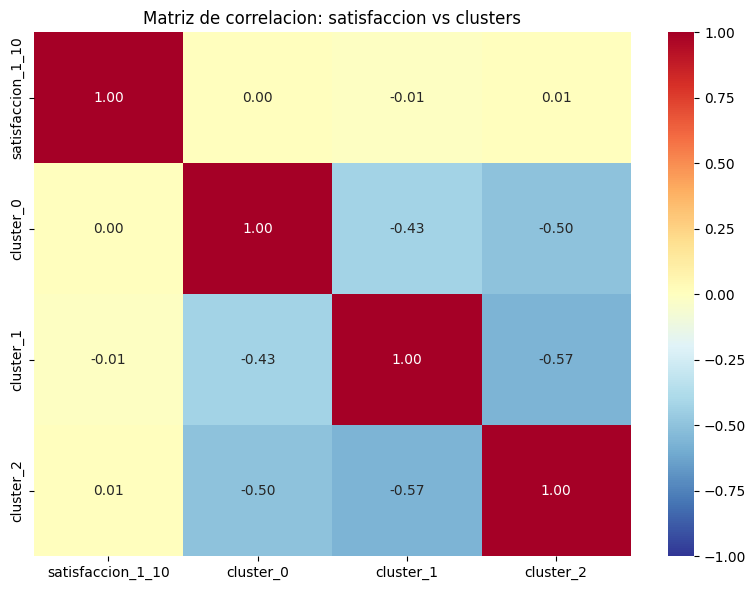

,satisfaccion_1_10,cluster_0,cluster_1,cluster_2
satisfaccion_1_10,1.000000,0.004211,-0.009499,0.005260
cluster_0,0.004211,1.000000,-0.427833,-0.501125
cluster_1,-0.009499,-0.427833,1.000000,-0.567778
cluster_2,0.005260,-0.501125,-0.567778,1.000000


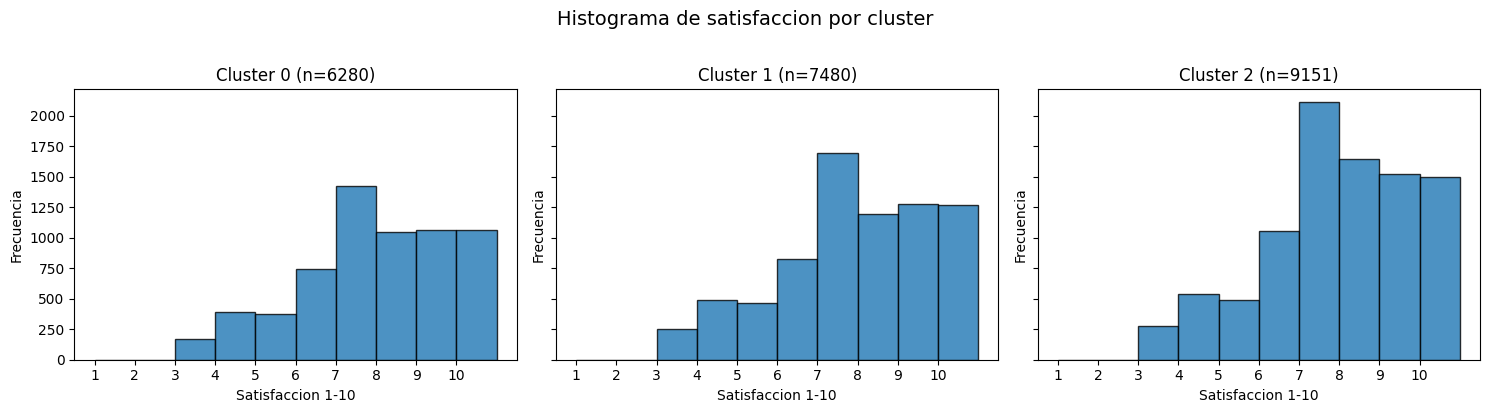

In [ ]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ruta base del proyecto (usa PPATH si existe; si no, infiere desde el cwd).
if "PPATH" in globals() and isinstance(PPATH, str):
    base_path = Path(PPATH)
else:
    cwd = Path.cwd()
    base_path = cwd if (cwd / "data").exists() else cwd.parent

# Asegura que exista df_clusters_in en memoria; si no, lo carga desde export.
if "df_clusters_in" not in globals() or df_clusters_in is None:
    df_clusters_in = pd.read_csv(base_path / "data" / "data_out" / "dataset_clusters_in.csv")

# Detecta la columna de cluster disponible.
if "cluster_kmeans" in df_clusters_in.columns:
    cluster_col = "cluster_kmeans"
elif "conv_cluster" in df_clusters_in.columns:
    cluster_col = "conv_cluster"
else:
    raise ValueError("No se encontro columna de cluster (cluster_kmeans o conv_cluster).")

# Asegura columna de satisfaccion.
if "satisfaccion_1_10" not in df_clusters_in.columns:
    if "df_usuarios" not in globals() or df_usuarios is None:
        df_usuarios = pd.read_csv(base_path / "data" / "hey_clientes.csv")
    df_clusters_in = df_clusters_in.merge(
        df_usuarios[["user_id", "satisfaccion_1_10"]],
        on="user_id",
        how="left",
    )

# Si tras merge queda duplicada, prioriza la version con menos nulos.
if "satisfaccion_1_10" not in df_clusters_in.columns:
    sat_candidates = [c for c in df_clusters_in.columns if c.startswith("satisfaccion_1_10")]
    if sat_candidates:
        non_nulls = {c: df_clusters_in[c].notna().sum() for c in sat_candidates}
        best_col = max(non_nulls, key=non_nulls.get)
        df_clusters_in["satisfaccion_1_10"] = df_clusters_in[best_col]
    else:
        raise ValueError("No se encontro columna de satisfaccion_1_10.")

# Limpieza basica para analisis.
df_analisis = df_clusters_in[[cluster_col, "satisfaccion_1_10"]].copy()
df_analisis["satisfaccion_1_10"] = pd.to_numeric(df_analisis["satisfaccion_1_10"], errors="coerce")
df_analisis = df_analisis.dropna(subset=[cluster_col, "satisfaccion_1_10"]).copy()
df_analisis[cluster_col] = pd.to_numeric(df_analisis[cluster_col], errors="coerce")
df_analisis = df_analisis.dropna(subset=[cluster_col]).copy()
df_analisis[cluster_col] = df_analisis[cluster_col].astype(int)

print("Filas usadas para analisis:", len(df_analisis))
print(df_analisis.head())

# MATRIZ DE CORRELACION: satisfaccion vs dummies de cluster (cada cluster).
cluster_dummies = pd.get_dummies(df_analisis[cluster_col], prefix="cluster")
corr_df = pd.concat([df_analisis[["satisfaccion_1_10"]], cluster_dummies], axis=1)
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", vmin=-1, vmax=1)
plt.title("Matriz de correlacion: satisfaccion vs clusters")
plt.tight_layout()
plt.show()

display(corr_matrix)

# HISTOGRAMA DE SATISFACCION POR CLUSTER.
clusters = sorted(df_analisis[cluster_col].unique())
n_clusters = len(clusters)
cols = min(3, n_clusters)
rows = math.ceil(n_clusters / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharey=True)
if not isinstance(axes, (list, tuple)) and hasattr(axes, "flatten"):
    axes = axes.flatten()
elif not isinstance(axes, (list, tuple)):
    axes = [axes]

for i, cl in enumerate(clusters):
    ax = axes[i]
    vals = df_analisis.loc[df_analisis[cluster_col] == cl, "satisfaccion_1_10"]
    bins = range(1, 12)  # escala 1..10
    ax.hist(vals, bins=bins, edgecolor="black", alpha=0.8)
    ax.set_title(f"Cluster {cl} (n={len(vals)})")
    ax.set_xlabel("Satisfaccion 1-10")
    ax.set_ylabel("Frecuencia")
    ax.set_xticks(range(1, 11))

for j in range(n_clusters, len(axes)):
    axes[j].axis("off")

fig.suptitle("Histograma de satisfaccion por cluster", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()